In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
networks = pd.read_csv("networkanomalydataset.csv")

# Brief Display of Dataset
networks.head()
networks.info()
networks.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Inbound Rate(bit/s)                1654 non-null   float64
 1   Outbound Rate(bit/s)               1654 non-null   float64
 2   Inbound Bandwidth Utilization(%)   1654 non-null   float64
 3   Outbound Bandwidth Utilization(%)  1654 non-null   float64
 4   Label                              1654 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.7 KB


,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
count,1.654000e+03,1.654000e+03,1.654000e+03,1.654000e+03,1654.000000
mean,2.062035e-16,-1.374690e-16,-6.873448e-17,2.062035e-16,0.500000
std,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,0.500151
min,-8.587873e-01,-8.451589e-01,-8.587677e-01,-8.450422e-01,0.000000
25%,-8.071507e-01,-8.063695e-01,-8.072172e-01,-8.064441e-01,0.000000
50%,-7.555341e-01,-7.747574e-01,-7.554490e-01,-7.751713e-01,0.500000
75%,9.628647e-01,1.112895e+00,9.627478e-01,1.112738e+00,1.000000
max,2.122913e+00,1.997753e+00,2.122901e+00,1.998350e+00,1.000000


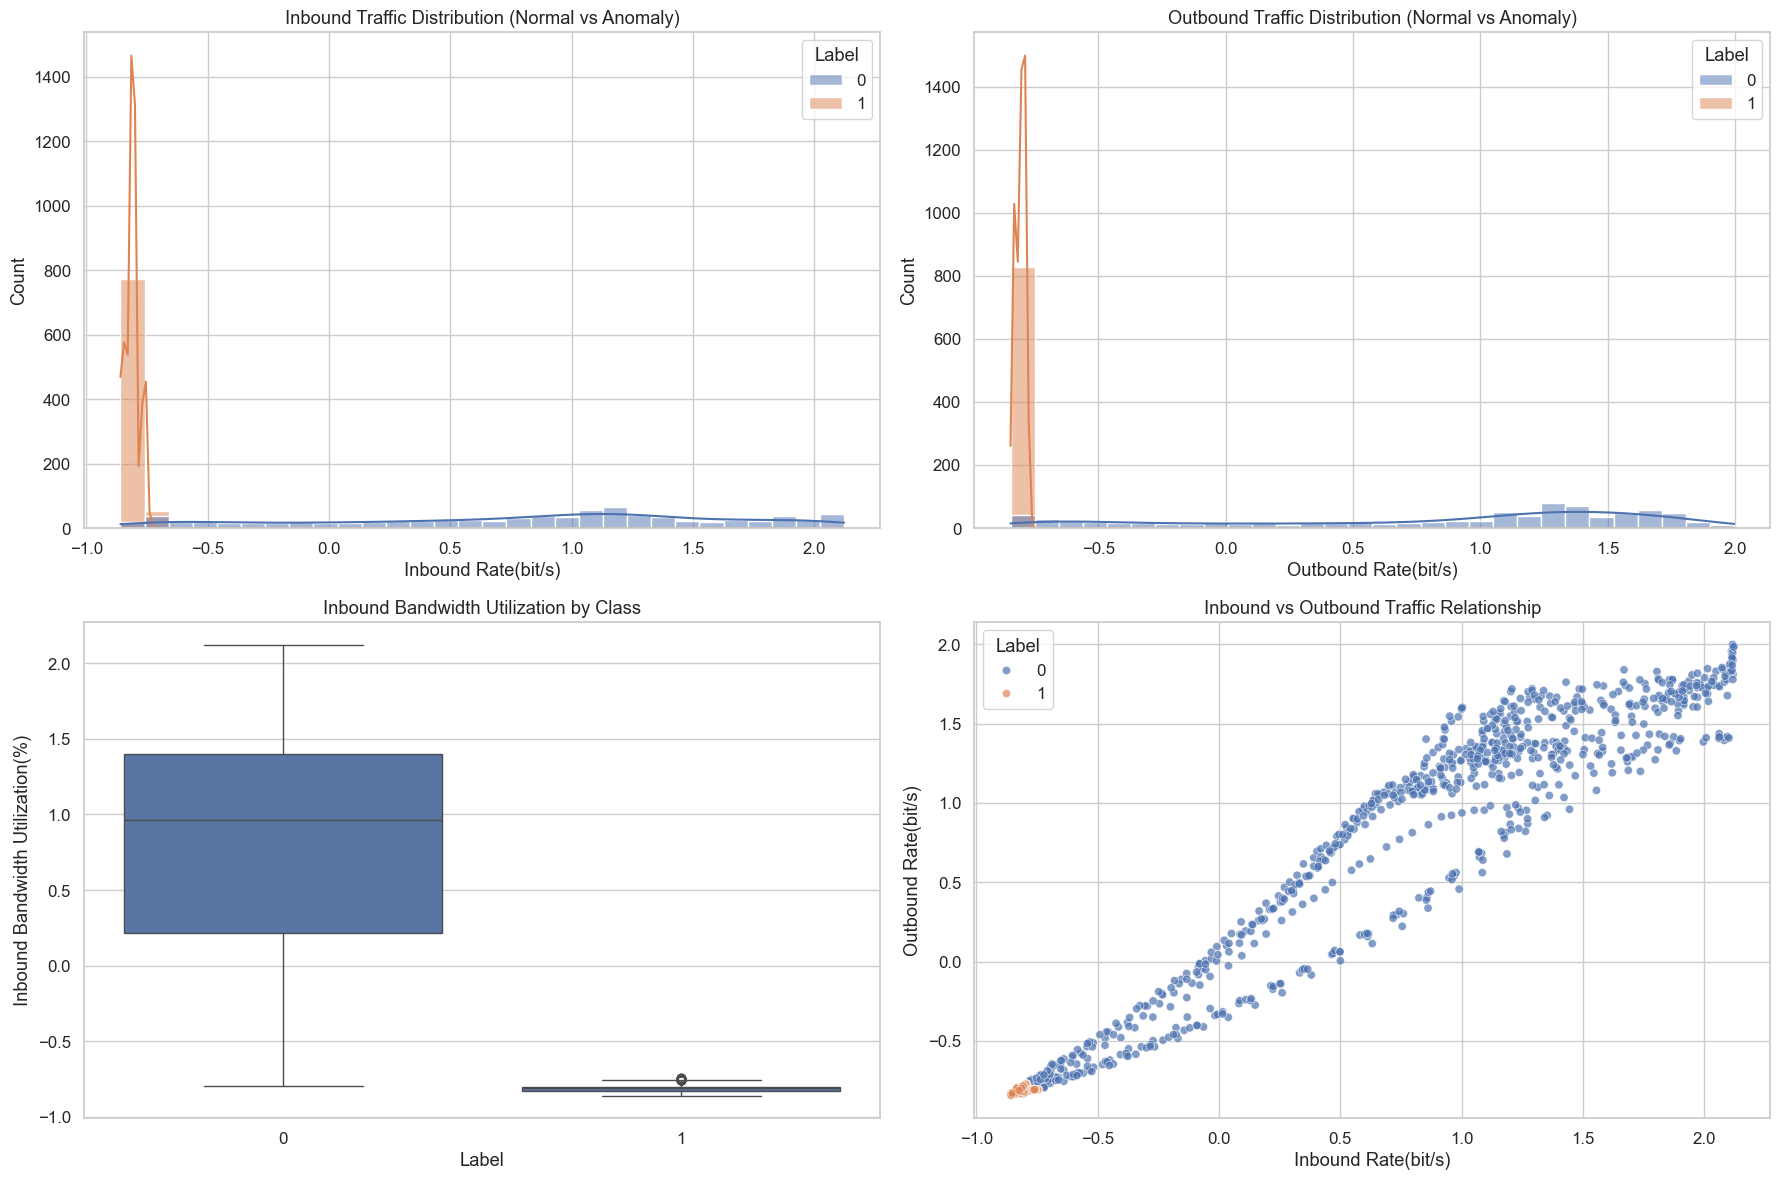

In [3]:
# ==============================
# Exploratory Data Analysis - Network Anomaly
# ==============================
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(18, 12))

# ------------------------------
# 1. Inbound Rate Distribution
# ------------------------------
plt.subplot(2, 2, 1)
sns.histplot(
    data=networks,
    x="Inbound Rate(bit/s)",
    hue="Label",
    bins=30,
    kde=True
)
plt.title("Inbound Traffic Distribution (Normal vs Anomaly)")

# ------------------------------
# 2. Outbound Rate Distribution
# ------------------------------
plt.subplot(2, 2, 2)
sns.histplot(
    data=networks,
    x="Outbound Rate(bit/s)",
    hue="Label",
    bins=30,
    kde=True
)
plt.title("Outbound Traffic Distribution (Normal vs Anomaly)")

# ------------------------------
# 3. Bandwidth Utilization
# ------------------------------
plt.subplot(2, 2, 3)
sns.boxplot(
    data=networks,
    x="Label",
    y="Inbound Bandwidth Utilization(%)"
)
plt.title("Inbound Bandwidth Utilization by Class")

# ------------------------------
# 4. Feature Relationship
# ------------------------------
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=networks,
    x="Inbound Rate(bit/s)",
    y="Outbound Rate(bit/s)",
    hue="Label",
    alpha=0.7
)
plt.title("Inbound vs Outbound Traffic Relationship")

plt.tight_layout()
plt.show()

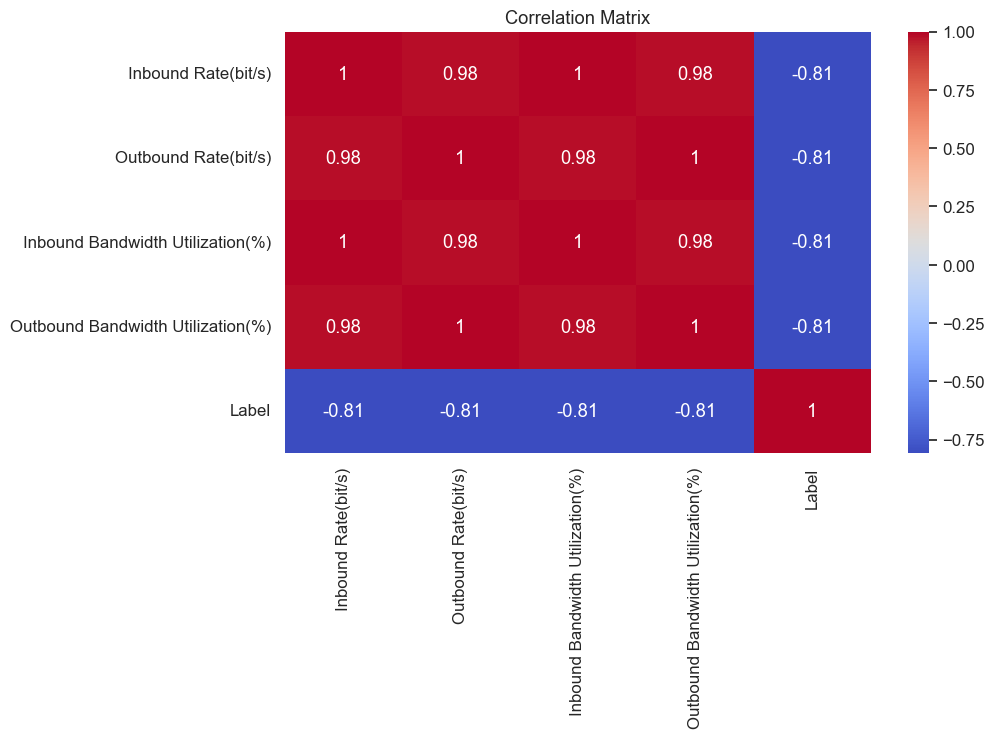

In [5]:
plt.figure(figsize=(18, 12))

# Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(networks.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

# Print
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

The purpose of this exploratory data analysis (EDA) is to understand the structure, relationships, and separability of features within the network anomaly dataset. This step is critical in determining whether machine learning models can effectively distinguish between normal network behavior and anomalous activity in a mission-critical cybersecurity context.

---

### 1. Dataset Characteristics

The dataset consists of four numerical features:
- Inbound Rate (bit/s)
- Outbound Rate (bit/s)
- Inbound Bandwidth Utilization (%)
- Outbound Bandwidth Utilization (%)

The target variable (`Label`) is binary:
- 0 = Normal network behavior
- 1 = Anomalous network activity

All features are standardized (mean ≈ 0, standard deviation ≈ 1), indicating that the dataset has been preprocessed using normalization techniques. While this improves model performance, it removes direct interpretability of real-world units (e.g., Mbps thresholds).

---

### 2. Feature Distributions

The distribution plots show a clear distinction between normal and anomalous traffic:

- **Normal traffic (Label = 0)** is widely distributed across higher values of inbound and outbound rates.
- **Anomalous traffic (Label = 1)** is tightly clustered around lower values.

This suggests that anomalies in this dataset are associated with **suppressed or abnormal traffic patterns**, rather than spikes. This is an important finding, as it differs from typical assumptions where anomalies are often associated with high-volume spikes (e.g., DDoS attacks).

---

### 3. Bandwidth Utilization Analysis

The boxplot of inbound bandwidth utilization reveals strong separation between classes:

- Normal traffic exhibits a wide range of utilization values.
- Anomalous traffic is tightly clustered at lower utilization levels.

This indicates that anomalies may correspond to:
- Link degradation
- Loss of communication
- System instability

In a defense and aerospace context, such patterns could represent degraded satellite links (e.g., KU or Inmarsat) or disrupted communication between systems.

---

### 4. Feature Relationships

The scatterplot of inbound versus outbound traffic shows a strong linear relationship between these variables. This is further supported by the correlation matrix.

Key observations:
- Inbound and outbound rates are **highly correlated (~0.98–1.0)**.
- Bandwidth utilization metrics are also strongly correlated with traffic rates.
- All features exhibit a strong negative correlation (~ -0.81) with the target variable.

This indicates:
- The dataset contains **high multicollinearity**, meaning several features provide redundant information.
- The target variable is strongly separable based on these features.

---

### 5. Correlation Analysis

The correlation heatmap highlights two important findings:

1. **Strong Feature Redundancy**  
   Nearly all input features are highly correlated with each other, suggesting overlapping information.

2. **Strong Predictive Signal**  
   The consistent negative correlation between features and the label indicates that anomalies are systematically different from normal observations.

---

### 6. Key Insights

From this EDA, several important conclusions can be drawn:

- The dataset is **highly structured and separable**, meaning machine learning models are likely to perform well.
- Anomalies are characterized by **low traffic and low utilization**, rather than high spikes.
- There is significant **multicollinearity**, which may influence model selection and interpretability.
- The dataset is balanced, which simplifies training but does not reflect real-world cybersecurity environments where anomalies are rare.

---

### 7. Implications for Modeling

These findings directly inform the modeling approach:

- **Logistic Regression** may perform well due to strong linear separability.
- **Tree-based models (e.g., Gradient Boosting)** can handle feature redundancy and capture nonlinear patterns.
- **Unsupervised methods (e.g., Isolation Forest)** are still relevant for simulating real-world scenarios where labels are unavailable.

Additionally, given the mission-critical nature of the problem:
- False negatives (missed anomalies) must be minimized.
- A cost-sensitive evaluation framework will be applied in later stages.

---

### 8. Operational Context

In real-world defense systems, such as satellite communication networks or UAV data links, anomalies may manifest as:

- Sudden drops in throughput
- Abnormally low bandwidth utilization
- Disruptions in inbound/outbound traffic symmetry

These findings demonstrate that the dataset captures patterns consistent with **network degradation or disruption scenarios**, reinforcing its relevance to cybersecurity and aerospace applications.